# Entrenamiento de modelo y EDA

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import linregress
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
df_coolers = pd.read_csv("C:\progra\Personal\Hack4Her2026\Hack4Her2026\data\Coolers.csv")

df_clientes = pd.read_csv("C:\progra\Personal\Hack4Her2026\Hack4Her2026\data\Clientes.csv")

df_train_raw = pd.read_csv('C:\progra\Personal\Hack4Her2026\Hack4Her2026\sales_churn_train.csv')

df_test_raw = pd.read_csv('C:\progra\Personal\Hack4Her2026\Hack4Her2026\data\sales_churn_test.csv')
df_test = df_test_raw.copy()

df_preds = pd.read_csv('C:\progra\Personal\Hack4Her2026\Hack4Her2026\data\preds_submission.csv')


In [3]:

print(f"  df_train_raw : {df_train_raw.shape}")
print(f"  df_test      : {df_test.shape}")
print(f"  df_coolers   : {df_coolers.shape}")
print(f"  df_clientes  : {df_clientes.shape}")
print(f"  df_preds     : {df_preds.shape}")


  df_train_raw : (5030534, 5)
  df_test      : (199923, 4)
  df_coolers   : (4636676, 4)
  df_clientes  : (371727, 4)
  df_preds     : (199923, 2)


In [9]:
from scipy.stats import linregress

def calcular_pendiente(g):
    if len(g) < 2:
        return 0.0
    return linregress(np.arange(len(g)), g['uni_boxes_sold_m'].values)[0]

def calcular_streak(s):
    """Calcula meses consecutivos sin compra desde el mes más reciente."""
    return int((s == 0).cumprod().sum())

def build_features_v2(df_transaccional_raw, df_clientes, df_coolers, es_train=True):
    df = df_transaccional_raw.sort_values(['customer_id', 'calmonth']).copy()
    if 'target' in df.columns:
        df = df.drop(columns=['target'])

    print("ANTES DEL FILTRO")
    print(df.columns)

    if es_train:

        # Orden cronológico
        df = df.sort_values(['customer_id', 'calmonth'])

        # Último registro de cada cliente
        idx_ultimo = (
            df.groupby('customer_id')['calmonth']
            .idxmax()
        )

        # Lo quitamos
        df = df.drop(index=idx_ultimo).reset_index(drop=True)

        print("DESPUÉS DEL FILTRO")
        print(df.columns)

    print("TIPO:", type(df))
    print("COLUMNAS:", list(df.columns))
    print("SHAPE:", df.shape)

    assert 'customer_id' in df.columns, (
        f"customer_id no existe. Columnas actuales: {list(df.columns)}"
    )

    # ── A. Histórico global ──────────────────────────────────
    agg_hist = df.groupby('customer_id').agg(
        num_meses              = ('calmonth',          'count'),
        total_cajas            = ('uni_boxes_sold_m',  'sum'),
        promedio_cajas         = ('uni_boxes_sold_m',  'mean'),
        std_cajas              = ('uni_boxes_sold_m',  'std'),
        max_cajas              = ('uni_boxes_sold_m',  'max'),
        min_cajas              = ('uni_boxes_sold_m',  'min'),
        total_transacciones    = ('num_transacciones', 'sum'),
        promedio_transacciones = ('num_transacciones', 'mean'),
        ultimo_calmonth        = ('calmonth',          'max'),
    ).reset_index()
    agg_hist['cv_cajas'] = agg_hist['std_cajas'] / (agg_hist['promedio_cajas'] + 0.1)

    # ── B. Últimos 3 meses ───────────────────────────────────
    agg_3m = (
        df.groupby('customer_id').tail(3)
          .groupby('customer_id').agg(
              promedio_cajas_3m         = ('uni_boxes_sold_m',  'mean'),
              promedio_transacciones_3m = ('num_transacciones', 'mean'),
              total_cajas_3m            = ('uni_boxes_sold_m',  'sum'),
          ).reset_index()
    )

    # ── C. Últimos 6 meses ───────────────────────────────────
    agg_6m = (
        df.groupby('customer_id').tail(6)
          .groupby('customer_id').agg(
              promedio_cajas_6m         = ('uni_boxes_sold_m',  'mean'),
              promedio_transacciones_6m = ('num_transacciones', 'mean'),
          ).reset_index()
    )

    # ── D. Pendiente lineal ──────────────────────────────────
    print("  → Calculando pendiente de ventas...")
    pendientes = (
        df.groupby('customer_id')
          .apply(calcular_pendiente)
          .reset_index()
          .rename(columns={0: 'pendiente_ventas'})
    )

    # ── E. Streak sin compra ─────────────────────────────────
    print("  → Calculando streak sin compra...")
    df['compro'] = (df['uni_boxes_sold_m'] > 0).astype(int)
    streak = (
        df.sort_values(['customer_id', 'calmonth'], ascending=[True, False])
          .groupby('customer_id')['compro']
          .apply(calcular_streak)
          .reset_index()
          .rename(columns={'compro': 'meses_sin_compra'})
    )

    # ── F. Consolidar variables transaccionales ──────────────
    feat = agg_hist.copy()
    for df_extra in [agg_3m, agg_6m, pendientes, streak]:
        feat = feat.merge(df_extra, on='customer_id', how='left')

    # Ratios e indicadores de caída
    feat['caida_3m_vs_hist'] = feat['promedio_cajas_3m'] / (feat['promedio_cajas'] + 0.1)
    feat['caida_6m_vs_hist'] = feat['promedio_cajas_6m'] / (feat['promedio_cajas'] + 0.1)
    feat['caida_3m_vs_6m']   = feat['promedio_cajas_3m'] / (feat['promedio_cajas_6m'] + 0.1)
    feat['caida_tx_3m']      = feat['promedio_transacciones_3m'] / (feat['promedio_transacciones'] + 0.1)

    # ── G. Infraestructura de Coolers ────────────────────────
    print("  → Agregando coolers...")
    coolers_last = (
        df_coolers.sort_values('calmonth')
                  .groupby('customer_id').last()
                  .reset_index()
                  [['customer_id', 'num_coolers', 'num_doors']]
    )
    coolers_tend = (
        df_coolers.sort_values(['customer_id', 'calmonth'])
                  .groupby('customer_id')
                  .apply(lambda g: linregress(np.arange(len(g)), g['num_coolers'].values)[0]
                         if len(g) >= 2 else 0.0)
                  .reset_index()
                  .rename(columns={0: 'pendiente_coolers'})
    )
    feat = feat.merge(coolers_last, on='customer_id', how='left')
    feat = feat.merge(coolers_tend, on='customer_id', how='left')
    feat['num_coolers']       = feat['num_coolers'].fillna(0)
    feat['num_doors']         = feat['num_doors'].fillna(0)
    feat['pendiente_coolers'] = feat['pendiente_coolers'].fillna(0)
    feat['sin_coolers']       = (feat['num_coolers'] == 0).astype(int)
    feat['eficiencia_cooler'] = feat['promedio_cajas'] / (feat['num_doors'] + 0.1)
    feat['cajas_por_cooler']  = feat['promedio_cajas'] / (feat['num_coolers'] + 0.1)

    # ── H. Clientes e Información Geográfica ─────────────────
    feat = feat.merge(df_clientes, on='customer_id', how='left')
    feat['rtm_customer_size_d'] = feat['rtm_customer_size_d'].fillna('Desconocido')

    return feat

In [10]:
# Preparación de la historia completa para el set de prueba
hist_para_test = pd.concat([
    df_train_raw[df_train_raw['customer_id'].isin(df_test['customer_id'])].drop(columns=['target']),
    df_test
], ignore_index=True).sort_values(['customer_id', 'calmonth'])

print("Procesando train (excluyendo último mes para evitar Data Leakage)...")
X_train_v2 = build_features_v2(df_train_raw, df_clientes, df_coolers, es_train=True)

print("\nProcesando test...")
X_test_v2  = build_features_v2(hist_para_test, df_clientes, df_coolers, es_train=False)

# Obtener target mapeado por cliente
df_y = df_train_raw.sort_values(['customer_id', 'calmonth']).groupby('customer_id').last()[['target']].reset_index()
y_v2 = X_train_v2.merge(df_y, on='customer_id', how='left')['target'].values

# Máscara para limpiar nulos de alineación de IDs
mask = ~np.isnan(y_v2)
y_v2 = y_v2[mask]

# CORRECCIÓN DE SESGO: Se añade 'num_meses' al drop antes de entrenar
X_v2      = X_train_v2[mask].drop(columns=['customer_id', 'ultimo_calmonth', 'num_meses']).copy()
X_test_v2 = X_test_v2.drop(columns=['customer_id', 'ultimo_calmonth', 'num_meses']).copy()

# Tratamiento de valores nulos estadísticos en clientes con un solo mes registrado
X_v2['std_cajas'] = X_v2['std_cajas'].fillna(0)
X_v2['cv_cajas']  = X_v2['cv_cajas'].fillna(0)
X_test_v2['std_cajas'] = X_test_v2['std_cajas'].fillna(0)
X_test_v2['cv_cajas']  = X_test_v2['cv_cajas'].fillna(0)

# Tratamiento unificado de variables categóricas
CAT_COLS = ['territory_d', 'comercial_subchannel_d', 'rtm_customer_size_d']
for col in CAT_COLS:
    X_v2[col]      = X_v2[col].astype('category')
    X_test_v2[col] = X_test_v2[col].astype('category')

cats = {col: X_v2[col].cat.categories.union(X_test_v2[col].cat.categories) for col in CAT_COLS}
for col in CAT_COLS:
    X_v2[col]      = X_v2[col].cat.set_categories(cats[col])
    X_test_v2[col] = X_test_v2[col].cat.set_categories(cats[col])

print("\n" + "─"*50)
print(f"X_v2 (Train Final) : {X_v2.shape}")
print(f"X_test_v2 (Test Final) : {X_test_v2.shape}")
print(f"Número de Churns en Train: {y_v2.sum():,.0f} ({y_v2.mean():.2%})")

Procesando train (excluyendo último mes para evitar Data Leakage)...
ANTES DEL FILTRO
Index(['customer_id', 'calmonth', 'num_transacciones', 'uni_boxes_sold_m'], dtype='str')
DESPUÉS DEL FILTRO
Index(['customer_id', 'calmonth', 'num_transacciones', 'uni_boxes_sold_m'], dtype='str')
TIPO: <class 'pandas.DataFrame'>
COLUMNAS: ['customer_id', 'calmonth', 'num_transacciones', 'uni_boxes_sold_m']
SHAPE: (4788729, 4)
  → Calculando pendiente de ventas...
  → Calculando streak sin compra...
  → Agregando coolers...

Procesando test...
ANTES DEL FILTRO
Index(['customer_id', 'calmonth', 'num_transacciones', 'uni_boxes_sold_m'], dtype='str')
TIPO: <class 'pandas.DataFrame'>
COLUMNAS: ['customer_id', 'calmonth', 'num_transacciones', 'uni_boxes_sold_m']
SHAPE: (4786636, 4)
  → Calculando pendiente de ventas...
  → Calculando streak sin compra...
  → Agregando coolers...

──────────────────────────────────────────────────
X_v2 (Train Final) : (240366, 28)
X_test_v2 (Test Final) : (199923, 28)
Númer

In [11]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score

print("=" * 50)
print("ENTRENAMIENTO — LightGBM 5-Fold Stratified CV (Sin Sesgo)")
print("=" * 50)

neg = (y_v2 == 0).sum()
pos = (y_v2 == 1).sum()
ratio = neg / pos
print(f"Ratio de desbalance de clases: {ratio:.2f}x\n")

params = {
    'objective':         'binary',
    'metric':            ['auc', 'average_precision'],
    'scale_pos_weight':  ratio,
    'learning_rate':     0.05,
    'num_leaves':        63,
    'min_child_samples': 50,
    'feature_fraction':  0.8,
    'bagging_fraction':  0.8,
    'bagging_freq':      5,
    'lambda_l1':         0.1,
    'lambda_l2':         0.1,
    'verbose':           -1,
    'random_state':      42,
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_v2   = np.zeros(len(X_v2))
test_v2  = np.zeros(len(X_test_v2))
modelos_v2 = []

for fold, (tr_idx, val_idx) in enumerate(cv.split(X_v2, y_v2)):
    X_tr, X_val = X_v2.iloc[tr_idx], X_v2.iloc[val_idx]
    y_tr, y_val = y_v2[tr_idx],      y_v2[val_idx]

    model = lgb.LGBMClassifier(**params, n_estimators=2000)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=0), # Silenciar iteraciones intermedias
        ]
    )

    oof_v2[val_idx] = model.predict_proba(X_val)[:, 1]
    test_v2        += model.predict_proba(X_test_v2)[:, 1] / 5
    modelos_v2.append(model)

    auc    = roc_auc_score(y_val, oof_v2[val_idx])
    pr_auc = average_precision_score(y_val, oof_v2[val_idx])
    print(f"Fold {fold+1} -> AUC: {auc:.4f} | PR-AUC: {pr_auc:.4f} | Árboles óptimos: {model.best_iteration_}")

print("\n" + "─" * 40)
print(f"Métrica Global OOF AUC    : {roc_auc_score(y_v2, oof_v2):.4f}")
print(f"Métrica Global OOF PR-AUC : {average_precision_score(y_v2, oof_v2):.4f}")

ENTRENAMIENTO — LightGBM 5-Fold Stratified CV (Sin Sesgo)
Ratio de desbalance de clases: 4.54x

Fold 1 -> AUC: 0.9851 | PR-AUC: 0.9414 | Árboles óptimos: 670
Fold 2 -> AUC: 0.9858 | PR-AUC: 0.9447 | Árboles óptimos: 779
Fold 3 -> AUC: 0.9853 | PR-AUC: 0.9439 | Árboles óptimos: 496
Fold 4 -> AUC: 0.9854 | PR-AUC: 0.9427 | Árboles óptimos: 769
Fold 5 -> AUC: 0.9847 | PR-AUC: 0.9413 | Árboles óptimos: 814

────────────────────────────────────────
Métrica Global OOF AUC    : 0.9852
Métrica Global OOF PR-AUC : 0.9426


In [12]:
# porcentaje de churns
print(f"Porcentaje de Churns en Test: {test_v2.mean():.2%}")

Porcentaje de Churns en Test: 7.02%


In [13]:
# Búsqueda del umbral que maximiza F1-Score
thresholds = np.arange(0.05, 0.95, 0.01)
f1_scores  = [f1_score(y_v2, (oof_v2 >= t).astype(int)) for t in thresholds]
best_t     = thresholds[np.argmax(f1_scores)]
best_f1    = max(f1_scores)

print(f"Threshold de negocio óptimo : {best_t:.2f}")
print(f"F1-Score alcanzado en OOF    : {best_f1:.4f}\n")

# Estructurar la predicción emparejando con el orden original de df_preds
pred_test = pd.DataFrame({
    'customer_id': df_preds['customer_id'].values,
    'churn_score': test_v2
})

df_submission = df_preds[['customer_id']].copy()
df_submission = df_submission.merge(pred_test, on='customer_id', how='left')
df_submission['target'] = (df_submission['churn_score'] >= best_t).astype(int)

# Guardar archivo oficial para plataforma
df_submission[['customer_id', 'target']].to_csv('submission.csv', index=False)
print(f"✓ submission.csv guardado correctamente.")
print(df_submission['target'].value_counts())

Threshold de negocio óptimo : 0.70
F1-Score alcanzado en OOF    : 0.8737

✓ submission.csv guardado correctamente.
target
0    193073
1      6850
Name: count, dtype: int64


In [15]:
import shap

# ── Importancia de características globales ──────────────────
imp_v2 = pd.DataFrame({
    'feature':    X_v2.columns,
    'importance': np.mean([m.feature_importances_ for m in modelos_v2], axis=0)
}).sort_values('importance', ascending=False)
print("Top 15 features reales del nuevo modelo:")
print(imp_v2.head(15).to_string(index=False))

# ── Cálculo de SHAP values sobre clientes en riesgo ──────────
print("\nCalculando SHAP values explicativos...")
explainer = shap.TreeExplainer(modelos_v2[0])

idx_riesgo  = np.where(test_v2 >= best_t)[0]
X_riesgo    = X_test_v2.iloc[idx_riesgo].reset_index(drop=True)
shap_values = explainer.shap_values(X_riesgo)

if isinstance(shap_values, list):
    sv = shap_values[1] # Clase positiva (Churn)
elif shap_values.ndim == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

df_shap = pd.DataFrame(sv, columns=X_v2.columns)

# Función para extraer la feature con mayor empuje hacia el riesgo
def razon_principal(shap_row, umbral=0.0):
    positivos = shap_row[shap_row > umbral].sort_values(ascending=False)
    if len(positivos) == 0:
        return 'score_general_alto'
    return positivos.index[0] # Corrected: Changed 'privados_index' to 'positivos.index[0]'

X_riesgo['razon_principal'] = df_shap.apply(razon_principal, axis=1)
X_riesgo['churn_score']     = test_v2[idx_riesgo]

# Diccionario mapeador de Causas y Acciones de Mitigación Reales
ACCIONES = {
    'pendiente_ventas':        ('Caída sostenida en ventas',            'Visita comercial urgente — revisar competencia y satisfacción'),
    'caida_3m_vs_hist':        ('Desaceleración reciente fuerte',       'Llamada proactiva — oferta de reactivación o promoción'),
    'caida_3m_vs_6m':          ('Aceleración de caída último trimestre','Alerta inmediata al ejecutivo de cuenta'),
    'caida_6m_vs_hist':        ('Declive progresivo de mediano plazo',  'Revisión de mix de productos y frecuencia de visita'),
    'caida_tx_3m':             ('Reducción de frecuencia de compra',    'Incentivar con descuento por volumen o frecuencia'),
    'meses_sin_compra':        ('Meses consecutivos sin comprar',       'Contacto inmediato — cliente posiblemente ya perdido'),
    'sin_coolers':             ('Sin infraestructura de frío activa',   'Gestión de equipos — revisar instalación o retiro de coolers'),
    'num_coolers':             ('Infraestructura reducida',             'Evaluar inversión en equipo adicional'),
    'eficiencia_cooler':       ('Baja eficiencia de coolers',           'Auditoría de uso de equipo en punto de venta'),
    'cv_cajas':                ('Alta variabilidad en compras',         'Estabilizar con contrato o acuerdo de volumen mínimo'),
    'promedio_cajas_3m':       ('Volumen bajo reciente',                'Revisión de portafolio — ampliar SKUs disponibles'),
    'promedio_transacciones_3m':('Pocas transacciones recientes',       'Aumentar frecuencia de visita del vendedor'),
    'total_cajas':             ('Bajo volumen histórico total',         'Revisar potencial del cliente y canal'),
}

def segmentar(row):
    razon = row['razon_principal']
    score = row['churn_score']
    nivel = 'Crítico' if score >= 0.90 else ('Alto' if score >= 0.80 else 'Medio')
    causa, accion = ACCIONES.get(razon, ('Comportamiento general de riesgo', 'Revisión integral del cliente'))
    return pd.Series({'nivel_riesgo': nivel, 'causa_principal': causa, 'accion_recomendada': accion})

segmentos = X_riesgo[['churn_score', 'razon_principal']].apply(segmentar, axis=1)
X_riesgo  = pd.concat([X_riesgo[['churn_score', 'razon_principal']], segmentos], axis=1)

# Recuperación de IDs geográficos y de negocio para el reporte final
ids_riesgo = df_preds['customer_id'].values[idx_riesgo]
X_riesgo.insert(0, 'customer_id', ids_riesgo)

reporte = (
    X_riesgo
    .merge(df_clientes, on='customer_id', how='left')
    .merge(
        df_coolers.sort_values('calmonth').groupby('customer_id').last().reset_index()[['customer_id', 'num_coolers', 'num_doors']],
        on='customer_id', how='left'
    )
    .sort_values('churn_score', ascending=False)
    [['customer_id', 'churn_score', 'nivel_riesgo', 'causa_principal',
      'accion_recomendada', 'territory_d', 'comercial_subchannel_d',
      'rtm_customer_size_d', 'num_coolers', 'num_doors']]
)

Top 15 features reales del nuevo modelo:
               feature  importance
   total_transacciones      3368.8
           total_cajas      3203.4
           territory_d      3088.2
      pendiente_ventas      2833.0
promedio_transacciones      2606.8
             min_cajas      2545.2
              cv_cajas      2373.8
           caida_tx_3m      2247.6
        caida_3m_vs_6m      2037.0
        promedio_cajas      2019.0
      caida_6m_vs_hist      1811.0
      caida_3m_vs_hist      1624.8
     eficiencia_cooler      1583.8
             std_cajas      1517.8
      cajas_por_cooler      1456.6

Calculando SHAP values explicativos...


In [16]:
print("\n" + "=" * 55)
print("RESUMEN EJECUTIVO (CORREGIDO Y SIN SESGO)")
print("=" * 55)

print(f"\nClientes totales en riesgo de Churn: {len(reporte):,}")

print("\nDistribución por nivel de riesgo:")
print(reporte['nivel_riesgo'].value_counts().to_string())

print("\nTop Causas Principales de Churn Reales (Verificadas por SHAP):")
print(reporte['causa_principal'].value_counts().head(5).to_string())

print("\nDistribución por territorio (Top 10):")
print(reporte.groupby('territory_d')['customer_id'].count().sort_values(ascending=False).head(10).to_string())

print("\nDistribución por subcanal:")
print(reporte.groupby('comercial_subchannel_d')['customer_id'].count().sort_values(ascending=False).head(10).to_string())

print("\nEjemplo de Clientes Críticos Reales con Acciones Estratégicas:")
cols_show = ['customer_id', 'churn_score', 'nivel_riesgo', 'causa_principal', 'accion_recomendada']
print(reporte[reporte['nivel_riesgo'] == 'Crítico'][cols_show].head(5).to_string(index=False))

# Guardar base comercial actionable
reporte.to_csv('reporte_comercial.csv', index=False)
print(f"\n✓ reporte_comercial.csv guardado con éxito ({len(reporte):,} clientes).")


RESUMEN EJECUTIVO (CORREGIDO Y SIN SESGO)

Clientes totales en riesgo de Churn: 6,850

Distribución por nivel de riesgo:
nivel_riesgo
Crítico    2938
Alto       2122
Medio      1790

Top Causas Principales de Churn Reales (Verificadas por SHAP):
causa_principal
Comportamiento general de riesgo     5137
Bajo volumen histórico total         1207
Reducción de frecuencia de compra     444
Caída sostenida en ventas              62

Distribución por territorio (Top 10):
territory_d
Guadalajara         832
Monterrey           695
Jalisco             623
Aguascalientes      441
Zacatecas           403
San Luis Potosi     387
Culiacan            315
Comarca Lagunera    313
Durango             287
Juarez              263

Distribución por subcanal:
comercial_subchannel_d
Abarrotes y bodegas               1809
Hogares                           1803
Kiosco                            1580
Licorería                          661
Verdulería                         230
Farmacia                        

# regresion logistica

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

print("Preparando matrices específicas para Regresión Logística...")

# 1. Identificar columnas numéricas y categóricas
num_cols = X_v2.select_dtypes(exclude=['category']).columns.tolist()
cat_cols = X_v2.select_dtypes(include=['category']).columns.tolist()

# 2. Copias de las matrices base
X_lr = X_v2.copy()
X_test_lr = X_test_v2.copy()

# 3. Escalar las variables numéricas
scaler = StandardScaler()
X_lr[num_cols] = scaler.fit_transform(X_lr[num_cols])
X_test_lr[num_cols] = scaler.transform(X_test_lr[num_cols])

# 4. Aplicar One-Hot Encoding a las categóricas
X_lr = pd.get_dummies(X_lr, columns=cat_cols, drop_first=True)
X_test_lr = pd.get_dummies(X_test_lr, columns=cat_cols, drop_first=True)

# Asegurar que ambos sets tengan exactamente las mismas columnas tras el One-Hot
X_lr, X_test_lr = X_lr.align(X_test_lr, join='left', axis=1, fill_value=0)

# Para Random Forest podemos usar Label Encoding rápido o rellenar dummies
X_rf = X_lr.copy()
X_test_rf = X_test_lr.copy()

print(f"✓ Matrices listas. Dimensiones para LR/RF: {X_lr.shape}")

Preparando matrices específicas para Regresión Logística...
✓ Matrices listas. Dimensiones para LR/RF: (240366, 65)


random y reg log

In [18]:
print("=" * 50)
print("ENTRENANDO BASELINE: REGRESIÓN LOGÍSTICA")
print("=" * 50)

oof_lr = np.zeros(len(X_lr))
test_lr = np.zeros(len(X_test_lr))

for fold, (tr_idx, val_idx) in enumerate(cv.split(X_lr, y_v2)):
    X_tr, X_val = X_lr.iloc[tr_idx], X_lr.iloc[val_idx]
    y_tr, y_val = y_v2[tr_idx], y_v2[val_idx]

    # Usamos class_weight='balanced' para compensar el desbalance de la señal
    model_lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, n_jobs=-1)
    model_lr.fit(X_tr, y_tr)

    oof_lr[val_idx] = model_lr.predict_proba(X_val)[:, 1]
    test_lr += model_lr.predict_proba(X_test_lr)[:, 1] / 5

auc_lr = roc_auc_score(y_v2, oof_lr)
pr_auc_lr = average_precision_score(y_v2, oof_lr)
print(f">> Baseline LR OOF AUC: {auc_lr:.4f} | PR-AUC: {pr_auc_lr:.4f}\n")


print("=" * 50)
print("ENTRENANDO COMPETIDOR: RANDOM FOREST")
print("=" * 50)

oof_rf = np.zeros(len(X_rf))
test_rf = np.zeros(len(X_test_rf))

for fold, (tr_idx, val_idx) in enumerate(cv.split(X_rf, y_v2)):
    X_tr, X_val = X_rf.iloc[tr_idx], X_rf.iloc[val_idx]
    y_tr, y_val = y_v2[tr_idx], y_v2[val_idx]

    # Ajustamos hiperparámetros base de RF para agilizar cómputo y controlar sobreajuste
    model_rf = RandomForestClassifier(n_estimators=150, max_depth=12, class_weight='balanced',
                                      random_state=42, n_jobs=-1)
    model_rf.fit(X_tr, y_tr)

    oof_rf[val_idx] = model_rf.predict_proba(X_val)[:, 1]
    test_rf += model_rf.predict_proba(X_test_rf)[:, 1] / 5

auc_rf = roc_auc_score(y_v2, oof_rf)
pr_auc_rf = average_precision_score(y_v2, oof_rf)
print(f">> Competidor RF OOF AUC: {auc_rf:.4f} | PR-AUC: {pr_auc_rf:.4f}")

ENTRENANDO BASELINE: REGRESIÓN LOGÍSTICA
>> Baseline LR OOF AUC: 0.9619 | PR-AUC: 0.8408

ENTRENANDO COMPETIDOR: RANDOM FOREST
>> Competidor RF OOF AUC: 0.9736 | PR-AUC: 0.9031


In [19]:
# porcentaje de churns
print(f"Porcentaje de Churns en Test (LR): {test_lr.mean():.2%}")
print(f"Porcentaje de Churns en Test (RF): {test_rf.mean():.2%}")


Porcentaje de Churns en Test (LR): 15.71%
Porcentaje de Churns en Test (RF): 15.43%


In [20]:
# 1. Recuperar métricas del LightGBM entrenado en la Celda 3
auc_lgb = roc_auc_score(y_v2, oof_v2)
pr_auc_lgb = average_precision_score(y_v2, oof_v2)

# Calcular F1 máximo para cada uno usando optimización de umbrales
def get_best_f1(y_true, oof_preds):
    ts = np.arange(0.1, 0.9, 0.01)
    scores = [f1_score(y_true, (oof_preds >= t).astype(int)) for t in ts]
    return max(scores)

f1_lr = get_best_f1(y_v2, oof_lr)
f1_rf = get_best_f1(y_v2, oof_rf)
f1_lgb = get_best_f1(y_v2, oof_v2)

# 2. Construir la tabla comparativa
df_metricas = pd.DataFrame({
    'Modelo': ['Regresión Logística (Baseline)', 'Random Forest (Competidor)', 'LightGBM (Modelo Propuesto)'],
    'OOF AUC-ROC (Discriminación)': [auc_lr, auc_rf, auc_lgb],
    'OOF PR-AUC (Precisión Promedio)': [pr_auc_lr, pr_auc_rf, pr_auc_lgb],
    'Max F1-Score (Balance Negocio)': [f1_lr, f1_rf, f1_lgb]
})

print("=" * 65)
print("TABLA COMPARATIVA DE RENDIMIENTO (VALIDACIÓN CRUZADA OOF)")
print("=" * 65)
print(df_metricas.to_string(index=False))
print("=" * 65)

# Guardar tabla como soporte de experimentación
df_metricas.to_csv('cuadro_comparativo_modelos.csv', index=False)
print("✓ Archivo 'cuadro_comparativo_modelos.csv' guardado.")

TABLA COMPARATIVA DE RENDIMIENTO (VALIDACIÓN CRUZADA OOF)
                        Modelo  OOF AUC-ROC (Discriminación)  OOF PR-AUC (Precisión Promedio)  Max F1-Score (Balance Negocio)
Regresión Logística (Baseline)                      0.961850                         0.840795                        0.792959
    Random Forest (Competidor)                      0.973623                         0.903109                        0.831065
   LightGBM (Modelo Propuesto)                      0.985202                         0.942615                        0.873721
✓ Archivo 'cuadro_comparativo_modelos.csv' guardado.


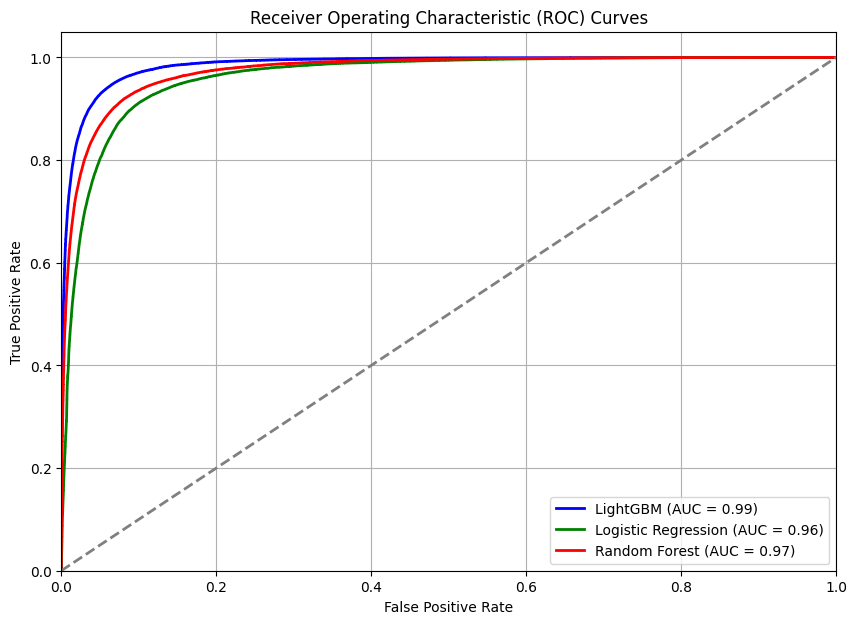

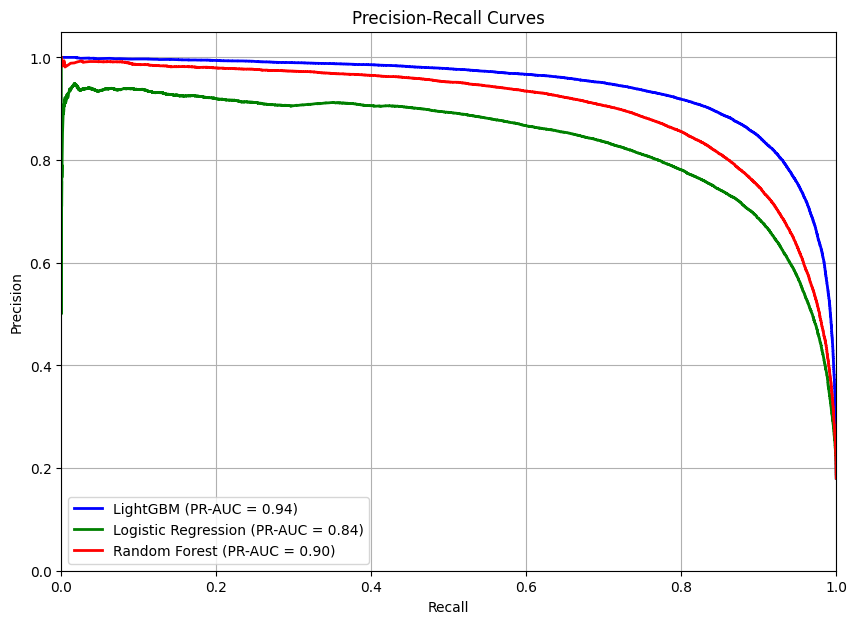

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, f1_score

# --- Plotting ROC Curves ---
plt.figure(figsize=(10, 7))

# LightGBM ROC
fpr_lgb, tpr_lgb, _ = roc_curve(y_v2, oof_v2)
roc_auc_lgb = auc(fpr_lgb, tpr_lgb)
plt.plot(fpr_lgb, tpr_lgb, color='blue', lw=2, label=f'LightGBM (AUC = {roc_auc_lgb:.2f})')

# Logistic Regression ROC
fpr_lr, tpr_lr, _ = roc_curve(y_v2, oof_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, color='green', lw=2, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')

# Random Forest ROC
fpr_rf, tpr_rf, _ = roc_curve(y_v2, oof_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, color='red', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')

plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curves')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# --- Plotting Precision-Recall Curves ---
plt.figure(figsize=(10, 7))

# LightGBM PR
precision_lgb, recall_lgb, _ = precision_recall_curve(y_v2, oof_v2)
pr_auc_lgb = auc(recall_lgb, precision_lgb)
plt.plot(recall_lgb, precision_lgb, color='blue', lw=2, label=f'LightGBM (PR-AUC = {pr_auc_lgb:.2f})')

# Logistic Regression PR
precision_lr, recall_lr, _ = precision_recall_curve(y_v2, oof_lr)
pr_auc_lr = auc(recall_lr, precision_lr)
plt.plot(recall_lr, precision_lr, color='green', lw=2, label=f'Logistic Regression (PR-AUC = {pr_auc_lr:.2f})')

# Random Forest PR
precision_rf, recall_rf, _ = precision_recall_curve(y_v2, oof_rf)
pr_auc_rf = auc(recall_rf, precision_rf)
plt.plot(recall_rf, precision_rf, color='red', lw=2, label=f'Random Forest (PR-AUC = {pr_auc_rf:.2f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


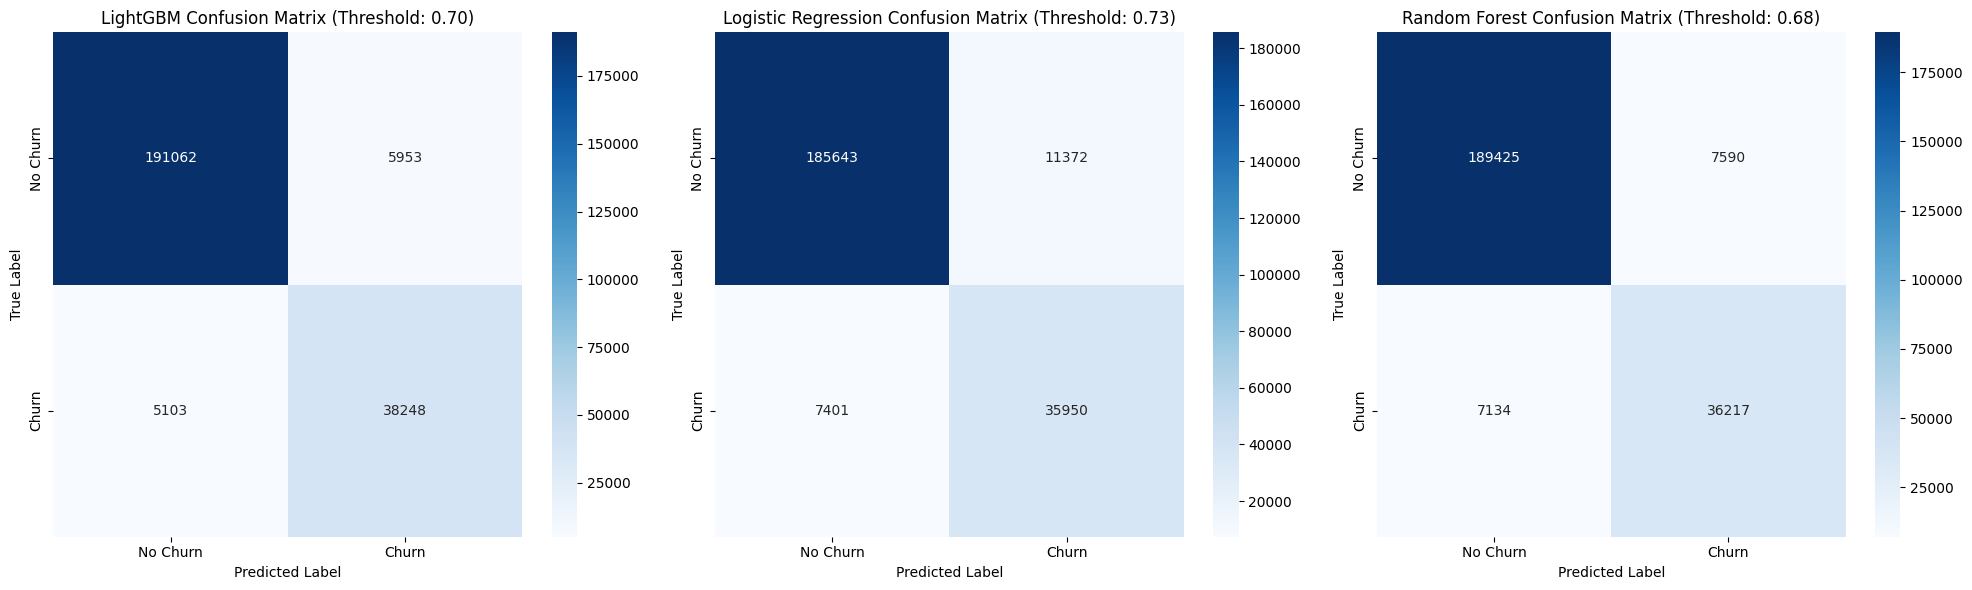

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred_proba, title, ax):
    # Find best F1 threshold for this model
    thresholds = np.arange(0.1, 0.9, 0.01)
    f1_scores  = [f1_score(y_true, (y_pred_proba >= t).astype(int)) for t in thresholds]
    best_t_model = thresholds[np.argmax(f1_scores)]

    y_pred = (y_pred_proba >= best_t_model).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(f'{title} (Threshold: {best_t_model:.2f})')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
    ax.set_xticklabels(['No Churn', 'Churn'])
    ax.set_yticklabels(['No Churn', 'Churn'])


fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# LightGBM Confusion Matrix
plot_confusion_matrix(y_v2, oof_v2, 'LightGBM Confusion Matrix', axes[0])

# Logistic Regression Confusion Matrix
plot_confusion_matrix(y_v2, oof_lr, 'Logistic Regression Confusion Matrix', axes[1])

# Random Forest Confusion Matrix
plot_confusion_matrix(y_v2, oof_rf, 'Random Forest Confusion Matrix', axes[2])

plt.tight_layout()
plt.show()

### Feature Importance for Logistic Regression

In [23]:
# Get feature importance for Logistic Regression (absolute coefficients)
# We'll use the last trained LR model (model_lr) from the cross-validation loop
# Note: This is an approximation as coefficients can be negative and directly reflect direction.
# Taking absolute values gives magnitude of influence.

lr_feature_importance = pd.DataFrame({
    'feature': X_lr.columns,
    'importance': np.abs(model_lr.coef_[0])
}).sort_values('importance', ascending=False)

print("Top 15 features for Logistic Regression:")
print(lr_feature_importance.head(15).to_string(index=False))

Top 15 features for Logistic Regression:
                         feature  importance
       promedio_transacciones_3m    9.089941
          promedio_transacciones    8.774565
             total_transacciones    7.346471
                  promedio_cajas    5.703122
                     total_cajas    4.607666
                       min_cajas    4.394861
               promedio_cajas_3m    4.334989
     rtm_customer_size_d_Pequeño    2.970588
       promedio_transacciones_6m    2.890055
                  total_cajas_3m    2.706830
     rtm_customer_size_d_Mediano    2.400469
        rtm_customer_size_d_Mini    2.149350
 comercial_subchannel_d_Farmacia    1.768582
                       std_cajas    1.666624
comercial_subchannel_d_Panadería    1.573523


### Feature Importance for Random Forest

In [24]:
# Get feature importance for Random Forest
# We'll use the last trained RF model (model_rf) from the cross-validation loop

rf_feature_importance = pd.DataFrame({
    'feature': X_rf.columns,
    'importance': model_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 features for Random Forest:")
print(rf_feature_importance.head(15).to_string(index=False))

Top 15 features for Random Forest:
                  feature  importance
      total_transacciones    0.147791
              total_cajas    0.140901
                min_cajas    0.092949
           total_cajas_3m    0.064653
promedio_transacciones_3m    0.059729
         pendiente_ventas    0.051719
 rtm_customer_size_d_Mini    0.050195
        promedio_cajas_3m    0.042096
              caida_tx_3m    0.040824
   promedio_transacciones    0.033686
           promedio_cajas    0.031803
promedio_transacciones_6m    0.031285
        promedio_cajas_6m    0.029581
           caida_3m_vs_6m    0.028727
         caida_3m_vs_hist    0.027347


### Visualizing Feature Importances

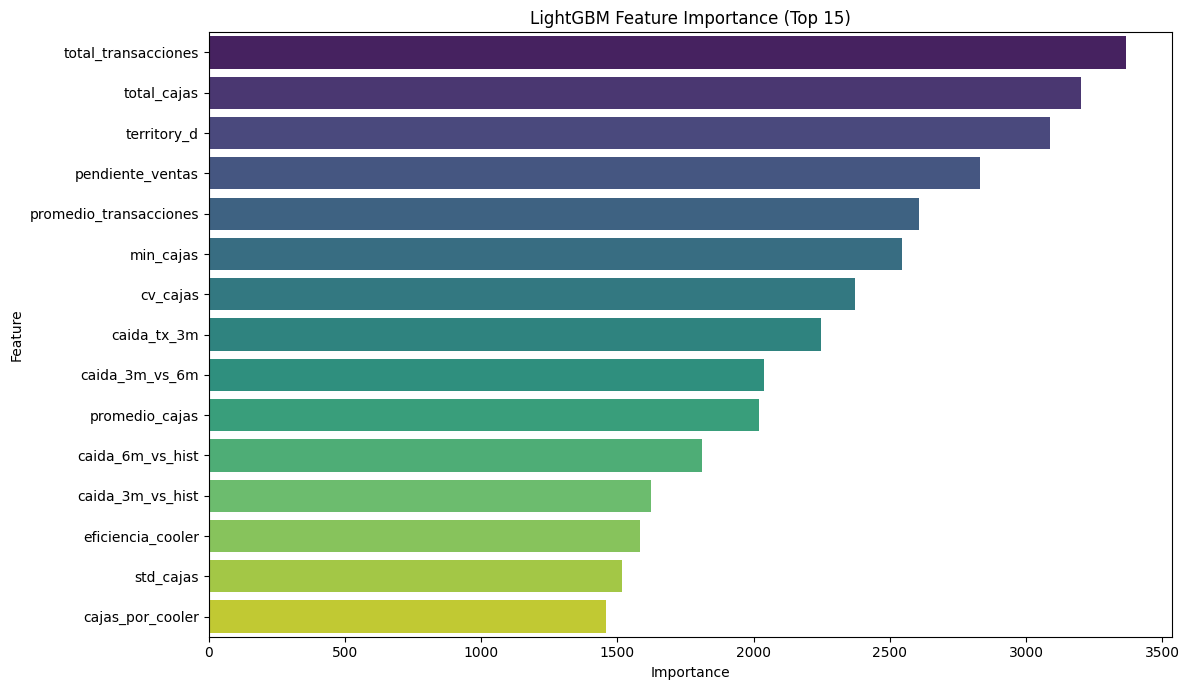

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='importance', y='feature', data=imp_v2.head(15), palette='viridis')
plt.title('LightGBM Feature Importance (Top 15)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

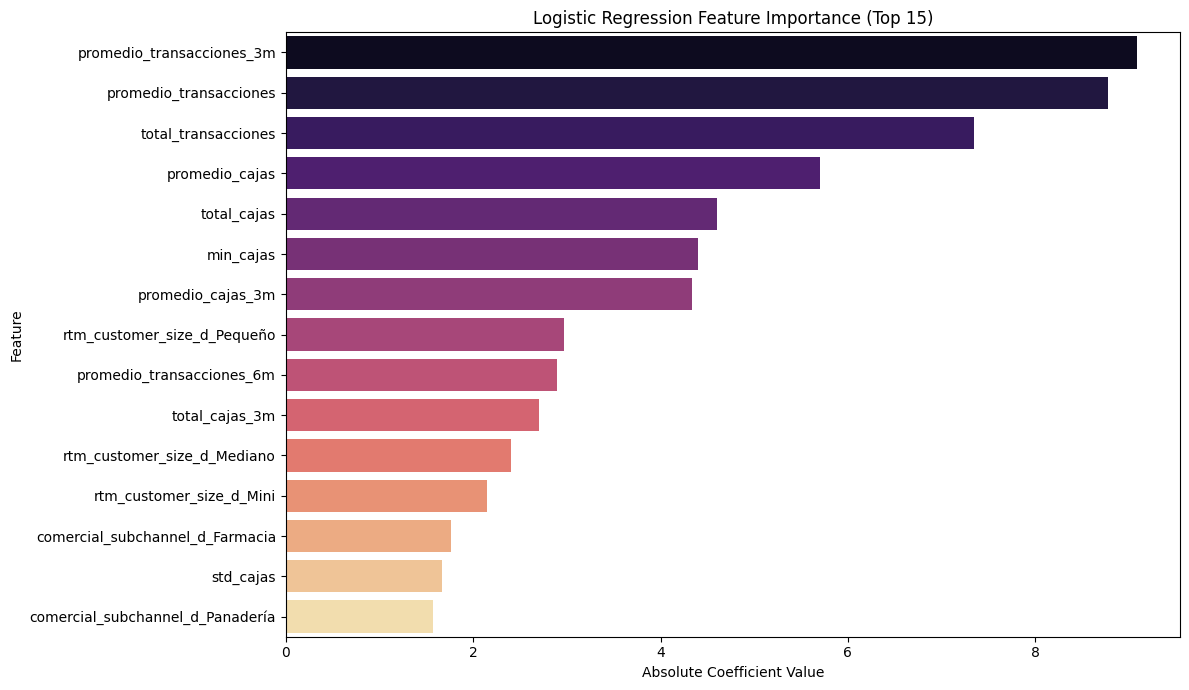

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='importance', y='feature', data=lr_feature_importance.head(15), palette='magma')
plt.title('Logistic Regression Feature Importance (Top 15)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

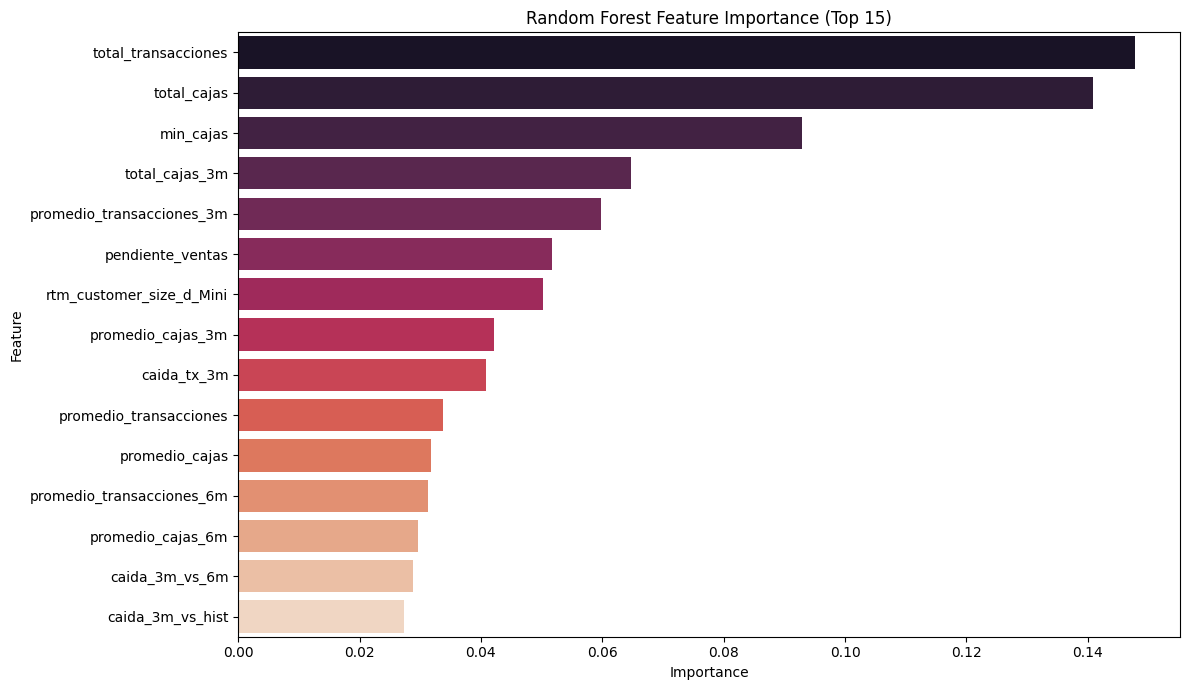

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='importance', y='feature', data=rf_feature_importance.head(15), palette='rocket')
plt.title('Random Forest Feature Importance (Top 15)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [28]:
print("=" * 50)
print("ENSEMBLE: Promedio Simple de Predicciones")
print("=" * 50)

# Promedio de las predicciones OOF (Out-Of-Fold) para el set de entrenamiento
oof_ensemble = (oof_v2 + oof_lr + oof_rf) / 3

# Promedio de las predicciones del set de prueba
test_ensemble = (test_v2 + test_lr + test_rf) / 3

# Calcular métricas para el ensemble en OOF
auc_ensemble = roc_auc_score(y_v2, oof_ensemble)
pr_auc_ensemble = average_precision_score(y_v2, oof_ensemble)
f1_ensemble = get_best_f1(y_v2, oof_ensemble) # Usar la función get_best_f1 definida antes

print(f">> Ensemble OOF AUC: {auc_ensemble:.4f} | PR-AUC: {pr_auc_ensemble:.4f} | Max F1-Score: {f1_ensemble:.4f}")

# Añadir el ensemble a la tabla comparativa
df_metricas_ensemble = df_metricas.copy()
df_metricas_ensemble.loc[len(df_metricas_ensemble)] = {
    'Modelo': 'Ensemble (Promedio Simple)',
    'OOF AUC-ROC (Discriminación)': auc_ensemble,
    'OOF PR-AUC (Precisión Promedio)': pr_auc_ensemble,
    'Max F1-Score (Balance Negocio)': f1_ensemble
}

print("\n" + "=" * 65)
print("TABLA COMPARATIVA DE RENDIMIENTO (CON ENSEMBLE)")
print("=" * 65)
print(df_metricas_ensemble.to_string(index=False))
print("=" * 65)

# Determinar el umbral óptimo para el ensemble
thresholds_ensemble = np.arange(0.05, 0.95, 0.01)
f1_scores_ensemble  = [f1_score(y_v2, (oof_ensemble >= t).astype(int)) for t in thresholds_ensemble]
best_t_ensemble     = thresholds_ensemble[np.argmax(f1_scores_ensemble)]
best_f1_ensemble    = max(f1_scores_ensemble)

print(f"\nThreshold de negocio óptimo para el Ensemble : {best_t_ensemble:.2f}")
print(f"F1-Score alcanzado en OOF para el Ensemble    : {best_f1_ensemble:.4f}")

# Crear archivo de submission con el ensemble
pred_test_ensemble = pd.DataFrame({
    'customer_id': df_preds['customer_id'].values,
    'churn_score': test_ensemble
})

df_submission_ensemble = df_preds[['customer_id']].copy()
df_submission_ensemble = df_submission_ensemble.merge(pred_test_ensemble, on='customer_id', how='left')
df_submission_ensemble['target'] = (df_submission_ensemble['churn_score'] >= best_t_ensemble).astype(int)

df_submission_ensemble[['customer_id', 'target']].to_csv('submission_ensemble.csv', index=False)
print(f"\n✓ submission_ensemble.csv guardado correctamente.")
print(df_submission_ensemble['target'].value_counts())

ENSEMBLE: Promedio Simple de Predicciones
>> Ensemble OOF AUC: 0.9799 | PR-AUC: 0.9247 | Max F1-Score: 0.8581

TABLA COMPARATIVA DE RENDIMIENTO (CON ENSEMBLE)
                        Modelo  OOF AUC-ROC (Discriminación)  OOF PR-AUC (Precisión Promedio)  Max F1-Score (Balance Negocio)
Regresión Logística (Baseline)                      0.961850                         0.840795                        0.792959
    Random Forest (Competidor)                      0.973623                         0.903109                        0.831065
   LightGBM (Modelo Propuesto)                      0.985202                         0.942615                        0.873721
    Ensemble (Promedio Simple)                      0.979917                         0.924707                        0.858131

Threshold de negocio óptimo para el Ensemble : 0.69
F1-Score alcanzado en OOF para el Ensemble    : 0.8581

✓ submission_ensemble.csv guardado correctamente.
target
0    192108
1      7815
Name: count, dtype: i

In [29]:
from sklearn.metrics import roc_auc_score
import pandas as pd

print("="*60)
print("AUDITORÍA DE VARIABLES INDIVIDUALES")
print("="*60)

resultados = []

for col in X_v2.select_dtypes(exclude='category').columns:

    try:
        auc = roc_auc_score(y_v2, X_v2[col])

        if auc < 0.5:
            auc = 1 - auc

        resultados.append((col, auc))

    except:
        pass

audit = (
    pd.DataFrame(resultados, columns=['variable', 'auc'])
      .sort_values('auc', ascending=False)
)

print(audit.head(20).to_string(index=False))

AUDITORÍA DE VARIABLES INDIVIDUALES
                 variable      auc
      total_transacciones 0.901110
              total_cajas 0.898477
           total_cajas_3m 0.885149
promedio_transacciones_3m 0.884339
                min_cajas 0.882285
        promedio_cajas_3m 0.881751
promedio_transacciones_6m 0.861235
        promedio_cajas_6m 0.860993
           promedio_cajas 0.844174
   promedio_transacciones 0.842081
                max_cajas 0.834513
                std_cajas 0.743737
                num_doors 0.735392
              num_coolers 0.710324
              caida_tx_3m 0.703042
                 cv_cajas 0.701487
         cajas_por_cooler 0.698049
         pendiente_ventas 0.679699
         caida_3m_vs_hist 0.663881
        eficiencia_cooler 0.663162


In [30]:
print("="*60)
print("TOP VARIABLES LIGHTGBM")
print("="*60)

imp_pct = imp_v2.copy()
imp_pct['pct_importance'] = (
    imp_pct['importance'] /
    imp_pct['importance'].sum()
)

print(
    imp_pct[['feature','pct_importance']]
    .head(15)
    .to_string(index=False)
)

TOP VARIABLES LIGHTGBM
               feature  pct_importance
   total_transacciones        0.077006
           total_cajas        0.073225
           territory_d        0.070592
      pendiente_ventas        0.064758
promedio_transacciones        0.059588
             min_cajas        0.058180
              cv_cajas        0.054262
           caida_tx_3m        0.051377
        caida_3m_vs_6m        0.046563
        promedio_cajas        0.046152
      caida_6m_vs_hist        0.041397
      caida_3m_vs_hist        0.037141
     eficiencia_cooler        0.036203
             std_cajas        0.034695
      cajas_por_cooler        0.033296


In [31]:
print("="*60)
print("ANÁLISIS TEMPORAL")
print("="*60)

tmp = X_train_v2.copy()
tmp['target'] = y_v2

print(
    tmp.groupby('ultimo_calmonth')['target']
       .mean()
       .sort_index()
)

ANÁLISIS TEMPORAL
ultimo_calmonth
202401    1.000000
202402    1.000000
202403    1.000000
202404    1.000000
202405    1.000000
202406    1.000000
202407    1.000000
202408    1.000000
202409    1.000000
202410    1.000000
202411    1.000000
202412    1.000000
202501    1.000000
202502    1.000000
202503    1.000000
202504    1.000000
202505    1.000000
202506    1.000000
202507    1.000000
202508    1.000000
202509    1.000000
202510    1.000000
202511    1.000000
202512    0.009193
Name: target, dtype: float64


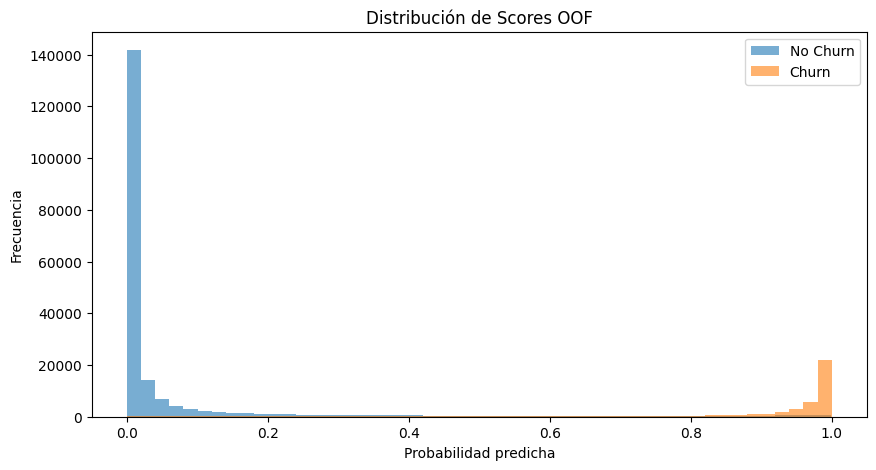

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    oof_v2[y_v2==0],
    bins=50,
    alpha=0.6,
    label='No Churn'
)

plt.hist(
    oof_v2[y_v2==1],
    bins=50,
    alpha=0.6,
    label='Churn'
)

plt.legend()
plt.title("Distribución de Scores OOF")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Frecuencia")

plt.show()

In [33]:
lift_df = pd.DataFrame({
    'target': y_v2,
    'score': oof_v2
})

lift_df = lift_df.sort_values(
    'score',
    ascending=False
)

lift_df['decil'] = pd.qcut(
    np.arange(len(lift_df)),
    10,
    labels=False
)

tabla_lift = (
    lift_df
    .groupby('decil')
    .agg(
        clientes=('target','count'),
        churns=('target','sum')
    )
)

tabla_lift['tasa_churn'] = (
    tabla_lift['churns'] /
    tabla_lift['clientes']
)

baseline = y_v2.mean()

tabla_lift['lift'] = (
    tabla_lift['tasa_churn'] /
    baseline
)

print(tabla_lift)

       clientes  churns  tasa_churn      lift
decil                                        
0         24037   23402    0.973582  5.398171
1         24037   16254    0.676208  3.749332
2         24036    3046    0.126727  0.702654
3         24037     429    0.017847  0.098958
4         24036     125    0.005201  0.028835
5         24037      53    0.002205  0.012226
6         24036      16    0.000666  0.003691
7         24037      11    0.000458  0.002537
8         24036      10    0.000416  0.002307
9         24037       5    0.000208  0.001153


In [34]:
top10 = int(len(lift_df)*0.10)

capturados = (
    lift_df.head(top10)['target']
    .sum()
)

total_churns = lift_df['target'].sum()

print("="*60)
print("EFECTIVIDAD OPERATIVA")
print("="*60)

print(
    f"Top 10% de clientes captura "
    f"{capturados/total_churns:.2%} "
    f"de todos los churns."
)

EFECTIVIDAD OPERATIVA
Top 10% de clientes captura 53.98% de todos los churns.


In [35]:
for pct in [0.05, 0.10, 0.20]:

    top_n = int(len(lift_df) * pct)

    capturados = (
        lift_df.head(top_n)['target']
        .sum()
    )

    total = lift_df['target'].sum()

    print(
        f"Top {pct:.0%}: "
        f"{capturados/total:.2%} de churns capturados"
    )

Top 5%: 27.46% de churns capturados
Top 10%: 53.98% de churns capturados
Top 20%: 91.48% de churns capturados


In [36]:
import joblib

# LightGBM model (last trained fold)
modelo_churn = modelos_v2[-1]

# Save as PKL
joblib.dump(modelo_churn, "modelo_churn.pkl")

# Save as native LightGBM TXT
modelo_churn.booster_.save_model("modelo_churn.txt")

print("✓ modelo_churn.pkl saved")
print("✓ modelo_churn.txt saved")

✓ modelo_churn.pkl saved
✓ modelo_churn.txt saved
